In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from PIL import Image
import cv2

In [4]:
# Install Kaggle
!pip install -q kaggle

import os

# Kaggle credentials
os.environ['KAGGLE_USERNAME'] = 'jyotirmayabehera'
os.environ['KAGGLE_KEY'] = 'KGAT_fa1af098d41a2070af04c51319501a08'

# Download dataset
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

# Extract dataset
!unzip -q new-plant-diseases-dataset.zip -d /content/dataset

print("Dataset downloaded and extracted successfully!")

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [02:42<00:00, 17.8MB/s]

Dataset downloaded and extracted successfully!


In [5]:
!find /content/dataset -type d | head -50

/content/dataset
/content/dataset/New Plant Diseases Dataset(Augmented)
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Corn_(maize)___Northern_Leaf_Blight
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Raspberry___healthy
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Squash___Powdery_mildew
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Peach___healthy
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Tomato___Leaf_Mold
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Potato___Late_blight
/conte

In [6]:
import os

dataset_path = "/content/dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    if len(root.split("/")) > 8:  # limit output
        continue

/content/dataset
/content/dataset/New Plant Diseases Dataset(Augmented)
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Corn_(maize)___Northern_Leaf_Blight
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Raspberry___healthy
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Squash___Powdery_mildew
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Peach___healthy
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Tomato___Leaf_Mold
/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Potato___Late_blight
/conte

In [7]:
TRAIN_DIR = "/content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train"

VALID_DIR = "/content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid"

In [8]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True

)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [9]:
class_names = train_ds.class_names

print("Number of Classes:", len(class_names))
print(class_names)

Number of Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

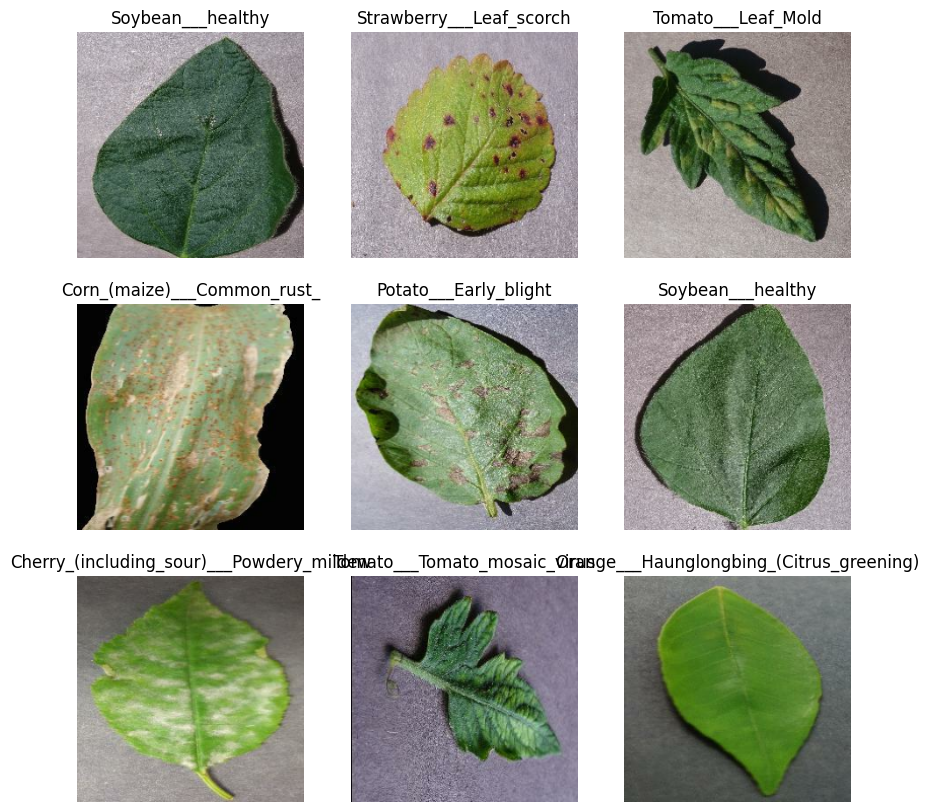

In [10]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [11]:
#optimize dataset
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)

In [12]:
#data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [13]:
#Build MobileNetV2 Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [14]:
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation='softmax'
)(x)

model = tf.keras.Model(inputs, outputs)

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        'best_leaf_model.keras',
        save_best_only=True,
        monitor='val_accuracy'
    )
]

In [17]:
#train model
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 191s 77ms/step - accuracy: 0.8547 - loss: 0.5024 - val_accuracy: 0.9141 - val_loss: 0.2626
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 164s 75ms/step - accuracy: 0.9157 - loss: 0.2626 - val_accuracy: 0.9258 - val_loss: 0.2327
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 206s 76ms/step - accuracy: 0.9218 - loss: 0.2375 - val_accuracy: 0.9261 - val_loss: 0.2304
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 164s 75ms/step - accuracy: 0.9260 - loss: 0.2244 - val_accuracy: 0.9375 - val_loss: 0.1911
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 161s 73ms/step - accuracy: 0.9277 - loss: 0.2181 - val_accuracy: 0.9435 - val_loss: 0.1724
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 160s 73ms/step - accuracy: 0.9298 - loss: 0.2146 - val_accuracy: 0.9386 - val_loss: 0.1831
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 160s 73ms/step - accuracy: 0.9308 - loss: 0.2072 - val_accuracy: 0.9446 - val_loss: 0.1708
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 158s 72ms/step - accuracy: 

In [18]:
#save model
model.save("leaf_disease_model.keras")

In [19]:
#save class name
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [20]:
#evaluate model
loss, accuracy = model.evaluate(valid_ds)

print("Accuracy:", accuracy)

550/550 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.9457 - loss: 0.1652
Accuracy: 0.9457091093063354


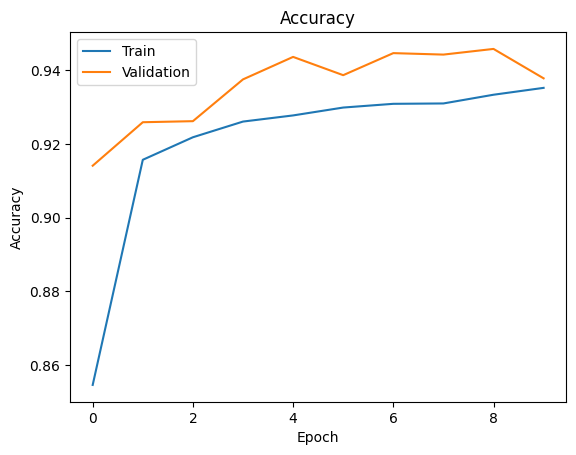

In [21]:
#Plot accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.show()

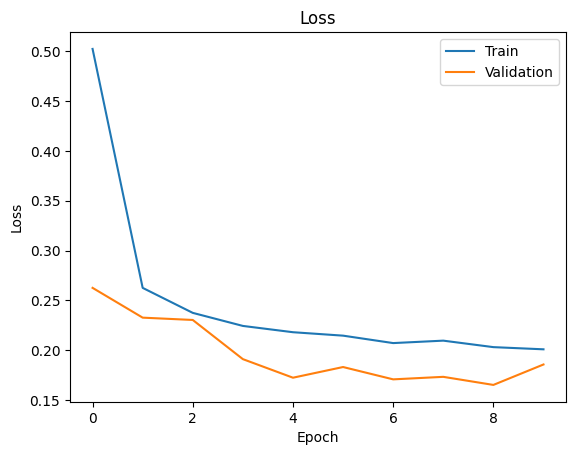

In [22]:
#plot loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])

plt.show()

In [23]:
#generate confustion matrix
y_true = np.concatenate(
    [y for x, y in valid_ds],
    axis=0
)

y_pred = np.argmax(
    model.predict(valid_ds),
    axis=1
)

cm = confusion_matrix(y_true, y_pred)

550/550 ━━━━━━━━━━━━━━━━━━━━ 32s 55ms/step


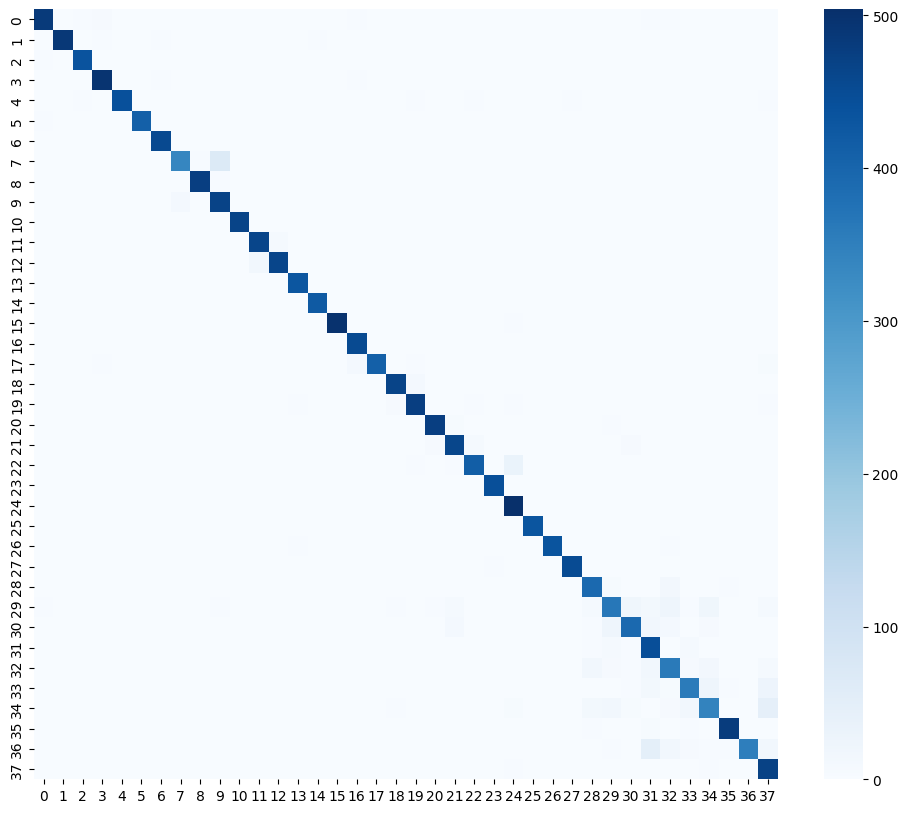

In [24]:
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.show()

In [25]:
#download save model
from google.colab import files

files.download("leaf_disease_model.keras")
files.download("class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import os

total_train = 0

for d in os.listdir(TRAIN_DIR):
    path = os.path.join(TRAIN_DIR, d)

    if os.path.isdir(path):
        img_count = len(os.listdir(path))
        total_train += img_count

        print(f"{d:40} : {img_count}")

print("\nTotal Training Images:", total_train)

Corn_(maize)___Northern_Leaf_Blight      : 1908
Raspberry___healthy                      : 1781
Squash___Powdery_mildew                  : 1736
Peach___healthy                          : 1728
Tomato___Leaf_Mold                       : 1882
Potato___Late_blight                     : 1939
Grape___Black_rot                        : 1888
Apple___Black_rot                        : 1987
Tomato___Bacterial_spot                  : 1702
Pepper,_bell___Bacterial_spot            : 1913
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 1642
Grape___Esca_(Black_Measles)             : 1920
Apple___Cedar_apple_rust                 : 1760
Peach___Bacterial_spot                   : 1838
Tomato___Spider_mites Two-spotted_spider_mite : 1741
Tomato___Early_blight                    : 1920
Grape___healthy                          : 1692
Blueberry___healthy                      : 1816
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1722
Strawberry___healthy                     : 1824
Cherry_(including_sour)